# 2.4. Ensembled techniques: Baging and RandomForest strategy behaviour

In [1]:
from anchoring_detection.models import Models
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn import metrics
from mlxtend.plotting import plot_confusion_matrix
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score, cross_val_predict

from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree


dataset = pd.read_pickle('/home/arturo/Documentos/Mooring_anomaly_detector/data/dataframe.pkl')

In [2]:
dataset

,Hs,Tp,Direction,m0_Surge,m0_Sway,Dragging
oc4__Hs1__Tp2__dir1__1,1.21,8.15,0,0.002438,0.001749,0
oc4__Hs1__Tp2__dir1__2,1.21,8.15,0,0.011784,0.008595,1
oc4__Hs1__Tp2__dir1__3,1.21,8.15,0,0.005411,0.005698,1
oc4__Hs1__Tp2__dir1__4,1.21,8.15,0,0.002285,0.003390,1
oc4__Hs1__Tp2__dir2__1,1.21,8.15,60,0.002250,0.001852,0
...,...,...,...,...,...,...
oc4__Hs4__Tp5__dir3__2,8.10,18.69,90,0.012230,0.018121,1
oc4__Hs4__Tp5__dir4__1,8.10,18.69,120,0.005428,0.010878,0
oc4__Hs4__Tp5__dir4__2,8.10,18.69,120,0.012206,0.016706,1
oc4__Hs4__Tp5__dir5__1,8.10,18.69,180,0.011085,0.002734,0


## Prepare data

The user can apply transformations described in [*models>transform_dataset*](/home/arturo/Documentos/Mooring_anomaly_detector/anchoring_detection/models.py)

In [3]:
drag_models = Models()

In [4]:
X_train_min_max, X_test_min_max, Y_train, Y_test = drag_models.transform_dataset(dataset)

The training set contains the Surge and Sway spectral moments in a 2D array

In [5]:
X_train_min_max

array([[0.00698358, 0.08528962],
       [0.01479205, 0.00191339],
       [0.00537408, 0.10163946],
       [0.07170368, 0.64738316],
       [0.13279204, 0.22928384],
       [0.97379166, 0.44280775],
       [0.02292324, 0.00992097],
       [0.02498603, 0.26900404],
       [0.03661853, 0.00448592],
       [0.46194614, 0.04524715],
       [0.05851568, 0.04525578],
       [0.80010464, 0.28760974],
       [0.00234019, 0.02315467],
       [0.59827887, 0.44251679],
       [0.54892333, 0.06513841],
       [0.59337273, 0.42081638],
       [0.60988548, 0.40667915],
       [0.57558169, 0.42438641],
       [0.67948669, 0.43384154],
       [0.        , 0.02048375],
       [0.61626008, 0.27170729],
       [0.66738549, 0.46234012],
       [0.58478244, 0.42107766],
       [0.02389493, 0.39263281],
       [0.12769059, 0.15162937],
       [0.07700594, 0.10509197],
       [0.61160497, 0.42066791],
       [0.65091093, 0.41372954],
       [0.00869242, 0.01133714],
       [0.01081056, 0.18879129],
       [0.

The approach of training is with supervised learning. It is store the data according two class, **Healthy (0)** and **Draging (1)**

In [6]:
Y_train

oc4__Hs1__Tp5__dir3__1    0
oc4__Hs1__Tp3__dir1__1    0
oc4__Hs1__Tp3__dir1__4    1
oc4__Hs4__Tp5__dir3__1    0
oc4__Hs2__Tp5__dir2__1    0
                         ..
oc4__Hs3__Tp5__dir5__1    0
oc4__Hs1__Tp3__dir1__3    1
oc4__Hs3__Tp4__dir4__1    0
oc4__Hs2__Tp3__dir1__4    1
oc4__Hs3__Tp5__dir3__1    0
Name: Dragging, Length: 96, dtype: int64

## First training

Check how model perform without hyperparams

In [7]:
rf_model = RandomForestClassifier(n_estimators=100, max_samples=40, n_jobs=-1)

In [8]:
rf_model.fit(X_train_min_max,Y_train)

RandomForestClassifier(max_samples=40, n_jobs=-1)

Due to the orthogonal nature of the decision boundaries in DecisionTree, it very easily falls into overfitting.

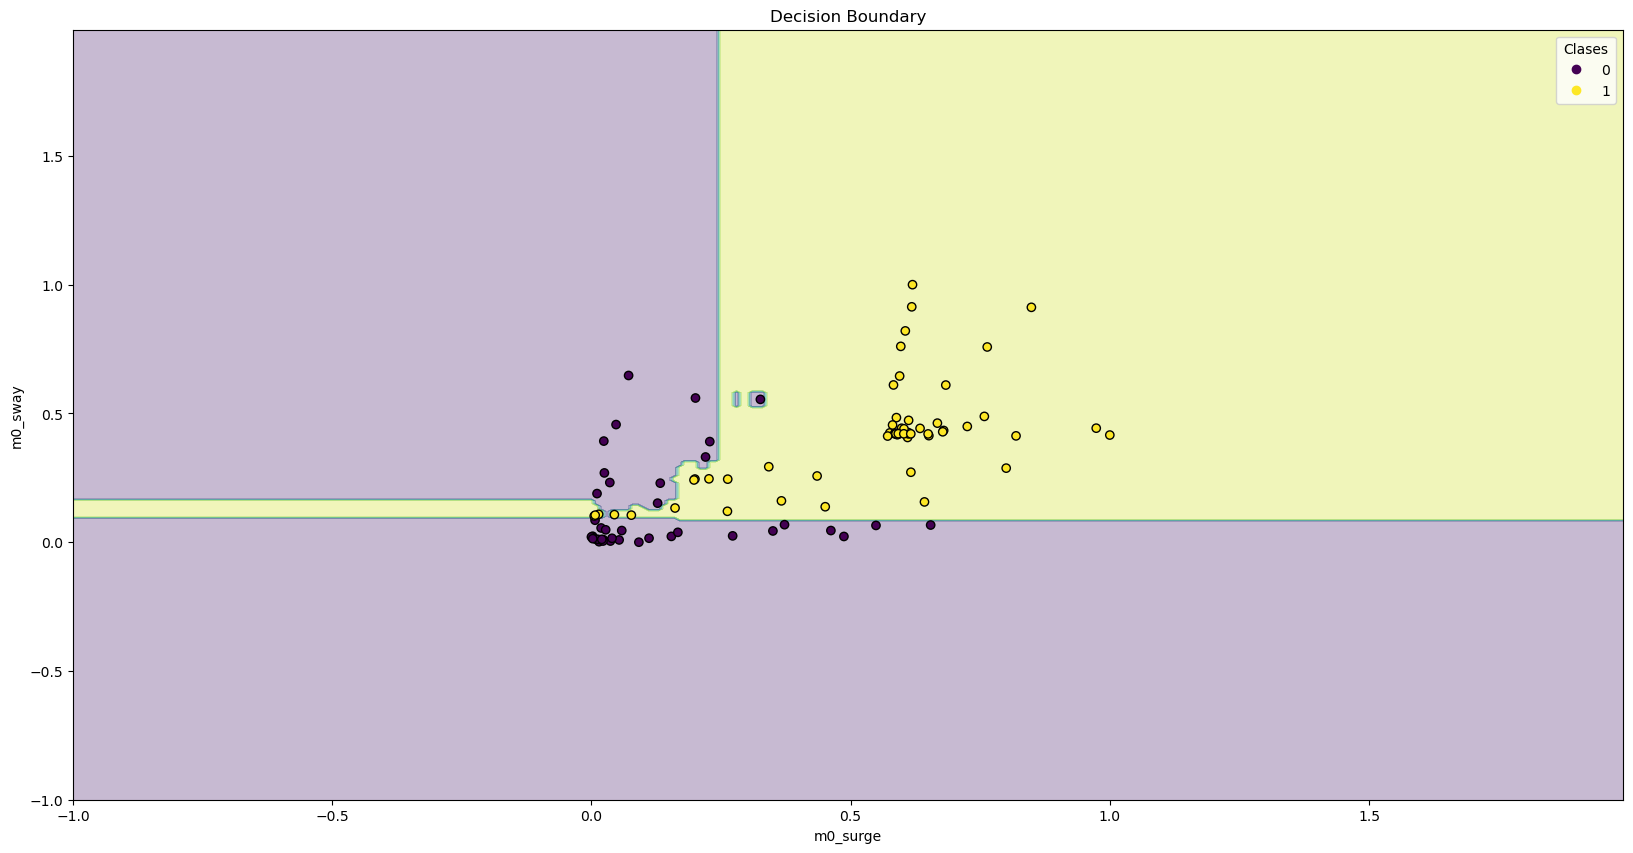

In [9]:
drag_models.decision_boundary(model=rf_model,X=X_train_min_max,y=Y_train)

Can be made cross validation and see the metrics

In [11]:
train_scores = cross_val_score(rf_model,X_train_min_max, Y_train, cv=5)

In [12]:
train_scores

array([1.        , 0.94736842, 1.        , 0.89473684, 0.89473684])

In [13]:
train_pred = cross_val_predict(rf_model,X_train_min_max, Y_train, cv=5)

In [14]:
cm, df_metrics =drag_models.return_metrics(Y=Y_train, Y_pred=train_pred)

In [15]:
df_metrics

,accuracy,precision,recall,f1
0,0.958333,0.949153,0.982456,0.965517


Text(0.5, 1.0, 'Bagging')

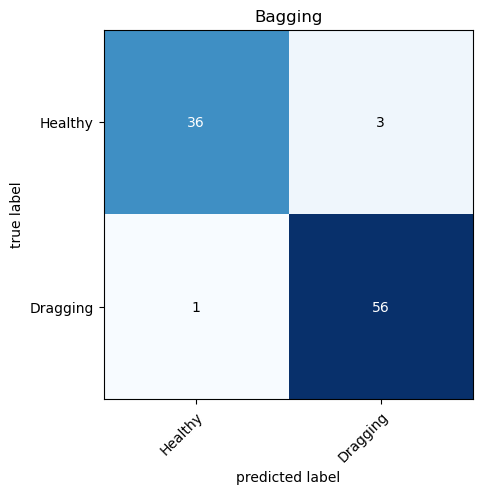

In [16]:
labels = ['Healthy','Dragging']

plot_confusion_matrix(conf_mat=cm,class_names=labels)
plt.title('Bagging')

## Hyperparams selection

In [42]:
param_grid = [
    {'n_estimators':[25, 50, 100, 150, 200],
     'max_samples':[20,40,60],
     'max_leaf_nodes':[None,2,3,4]}
    ]

grid_search = GridSearchCV(rf_model, param_grid,  cv=5, scoring= ['accuracy','precision','recall','f1'],refit='accuracy', return_train_score=True)

grid_search.fit(X_train_min_max,Y_train)

GridSearchCV(cv=5,
             estimator=RandomForestClassifier(max_samples=40, n_estimators=300,
                                              n_jobs=-1, oob_score=True),
             param_grid=[{'max_leaf_nodes': [None, 2, 3, 4],
                          'max_samples': [20, 40, 60],
                          'n_estimators': [25, 50, 100, 150, 200]}],
             refit='accuracy', return_train_score=True,
             scoring=['accuracy', 'precision', 'recall', 'f1'])

In [43]:
hyperparams = pd.DataFrame(grid_search.cv_results_)
metric_columns = ['param_n_estimators', 'param_max_samples', 'param_max_leaf_nodes', 'mean_train_accuracy', 'mean_train_precision', 'mean_train_recall', 'mean_train_f1']

hyperparams = hyperparams[metric_columns]

hyperparams

,param_n_estimators,param_max_samples,param_max_leaf_nodes,mean_train_accuracy,mean_train_precision,mean_train_recall,mean_train_f1
0,25,20,None,0.927033,0.928267,0.956135,0.940174
1,50,20,None,0.963500,0.958651,0.982415,0.969779
2,100,20,None,0.989576,0.991397,0.991304,0.991207
3,150,20,None,0.974026,0.962574,0.995652,0.978629
4,200,20,None,0.963602,0.961539,0.978164,0.969453
5,25,40,None,0.994805,0.995745,0.995556,0.995602
6,50,40,None,0.997403,0.995745,1.000000,0.997849
7,100,40,None,1.000000,1.000000,1.000000,1.000000
8,150,40,None,0.997368,0.995652,1.000000,0.997802
9,200,40,None,1.000000,1.000000,1.000000,1.000000


In [44]:
grid_search.best_params_

{'max_leaf_nodes': None, 'max_samples': 40, 'n_estimators': 50}

## New training

Retraining model with hyperparameters

In [69]:
rf_model = RandomForestClassifier(n_estimators=300, max_samples=40, n_jobs=-1, oob_score=True)

In [70]:
rf_model.fit(X_train_min_max,Y_train)

RandomForestClassifier(max_samples=40, n_estimators=300, n_jobs=-1,
                       oob_score=True)

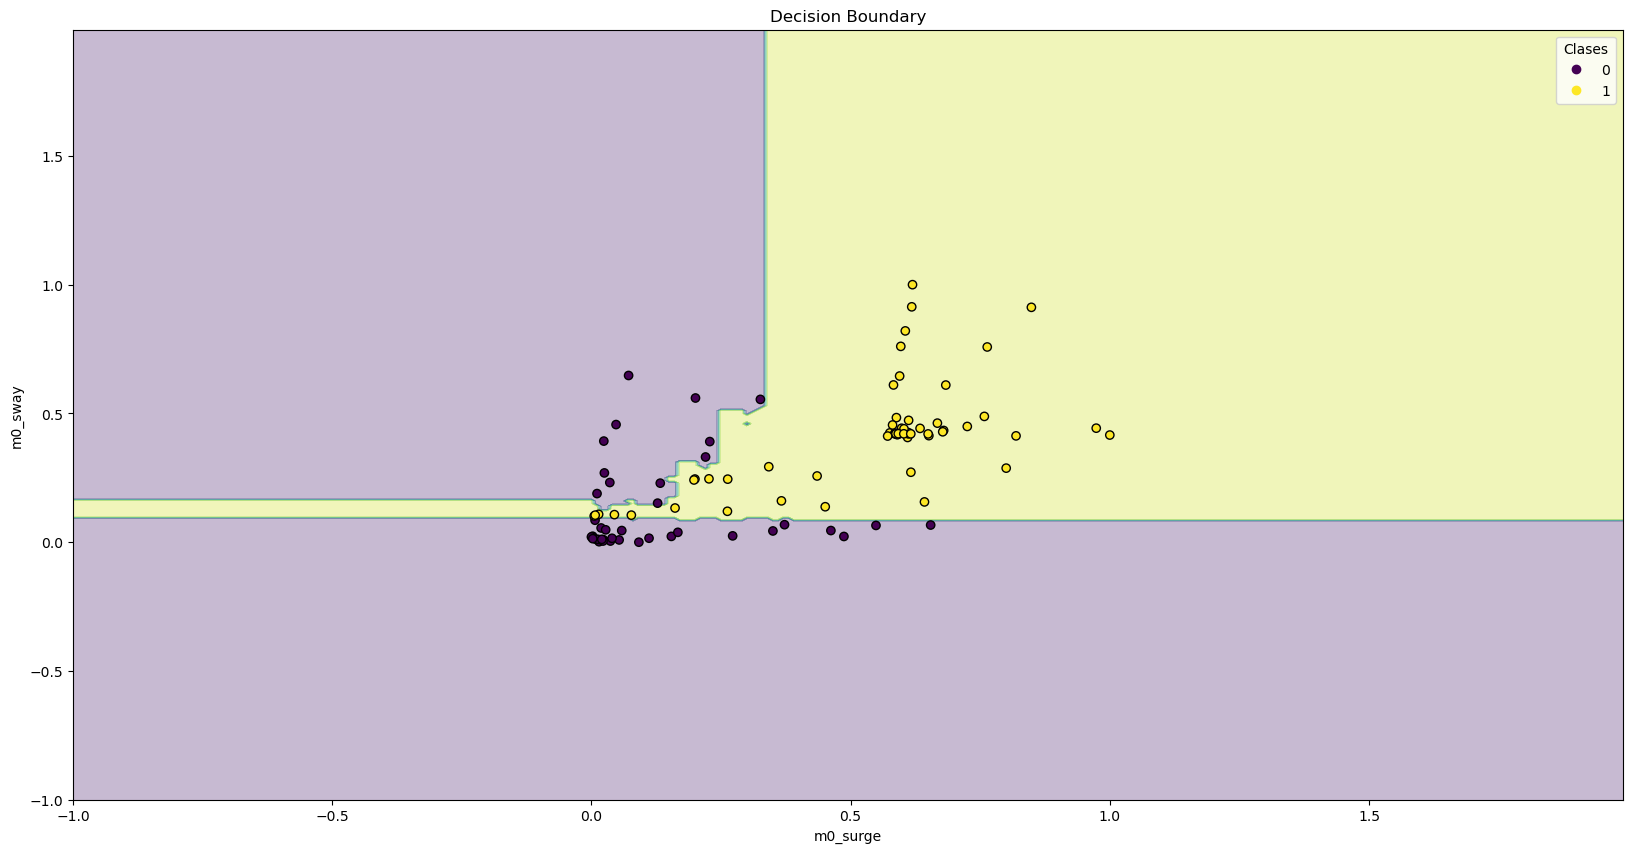

In [71]:
drag_models.decision_boundary(rf_model,X=X_train_min_max,y=Y_train)

In [72]:
rf_model.oob_score_

0.9479166666666666

In [73]:
train_scores = cross_val_score(rf_model,X_train_min_max, Y_train, cv=5)

In [74]:
train_scores

array([1.        , 0.94736842, 1.        , 0.89473684, 1.        ])

In [75]:
train_pred = cross_val_predict(rf_model,X_train_min_max, Y_train, cv=5)

In [76]:
cm, df_metrics =drag_models.return_metrics(Y=Y_train, Y_pred=train_pred)

Good metrics in the training phase. However, it fails to draw a fully continuous decision boundary (if you look, isolated circles of class 0 appear in the middle of the class 1 area). Increasing n_estimators reduces this problem to some extent, but using so many trees in parallel for such a low dataset, the model will end up overfitting.

In [77]:
df_metrics

,accuracy,precision,recall,f1
0,0.958333,0.964912,0.964912,0.964912


Text(0.5, 1.0, 'Decision tree')

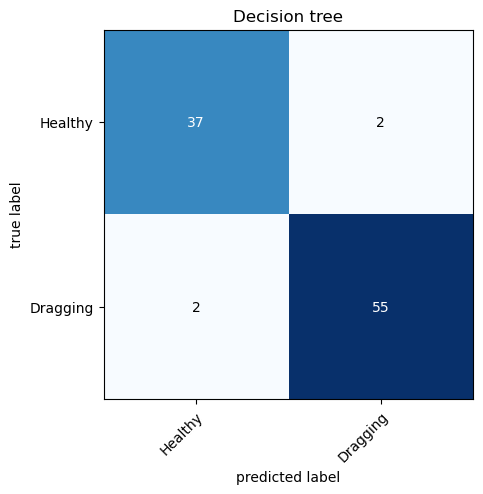

In [78]:
labels = ['Healthy','Dragging']

plot_confusion_matrix(conf_mat=cm,class_names=labels)
plt.title('Decision tree')

## Predictions

In [79]:
Y_pred_test = rf_model.predict(X_test_min_max)

ATTENTION: Note that you are now working with model test arrays.

In [80]:
cm, df_metrics =drag_models.return_metrics(Y=Y_test, Y_pred=Y_pred_test)

In [81]:
df_metrics

,accuracy,precision,recall,f1
0,1.0,1.0,1.0,1.0


Text(0.5, 1.0, 'Decision tree')

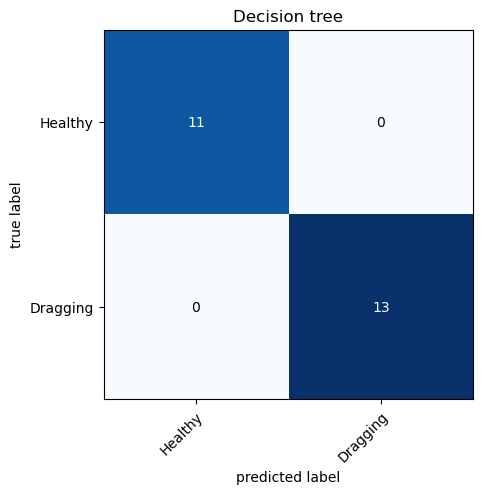

In [82]:
labels = ['Healthy','Dragging']

plot_confusion_matrix(conf_mat=cm,class_names=labels)
plt.title('Decision tree')

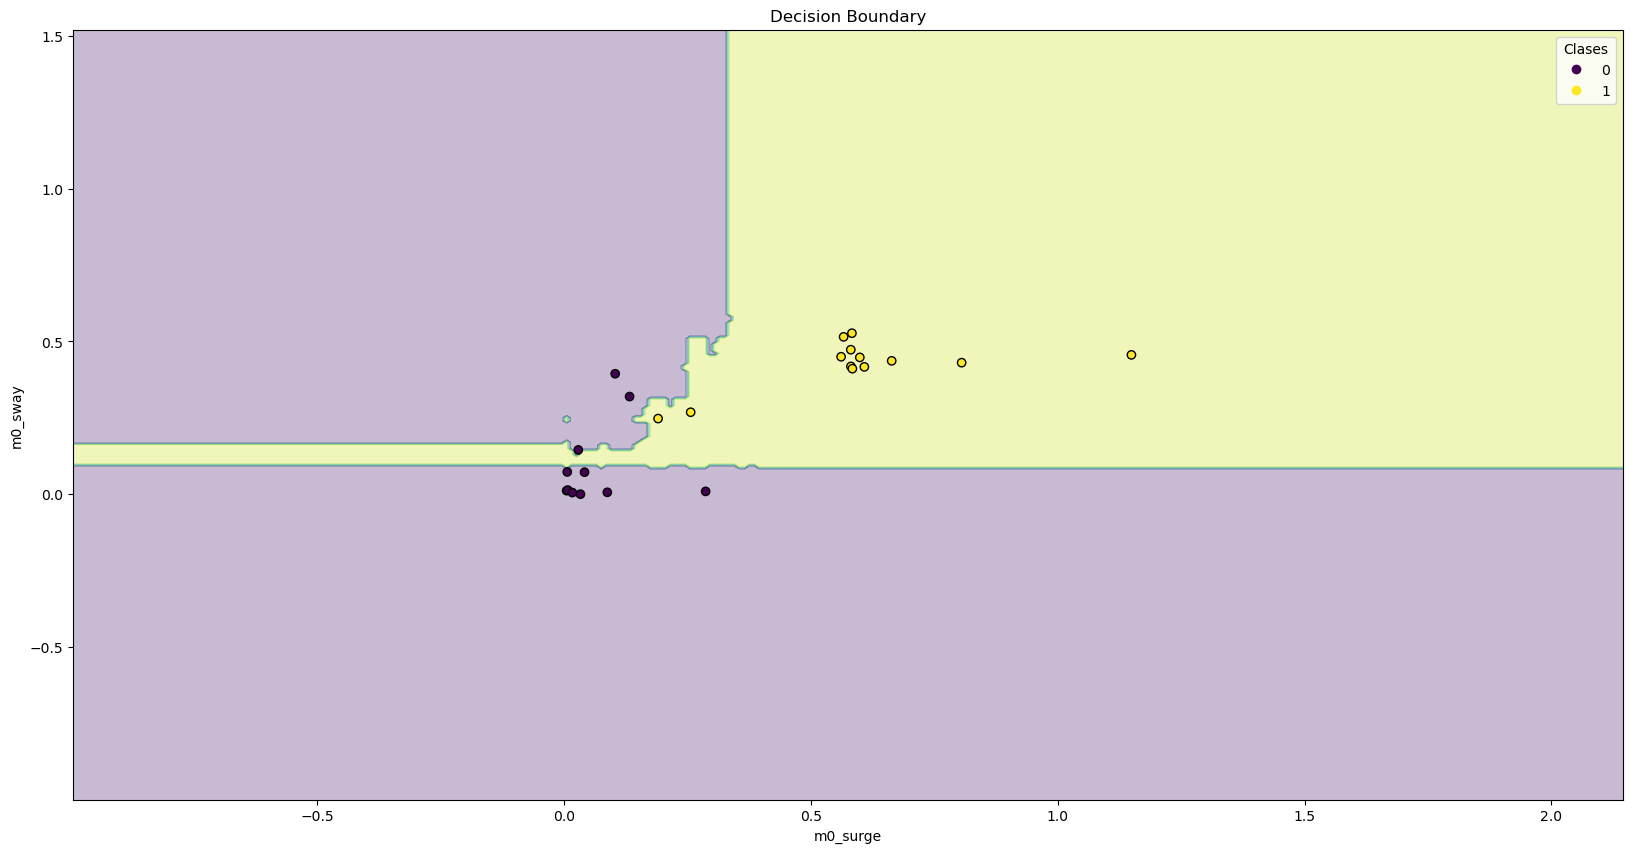

In [83]:
drag_models.decision_boundary(rf_model,X=X_test_min_max,y=Y_test)

The same discontinuous behaviour on the decision frontier is repeated in the predictions. This is good practice in the future, but there is a lack of data to make a better distinction and reduce overfitting.